In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.Cartpole_Control_Utils import *
import time

c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Run one episode

True length: 0.5, Model length: 1.0


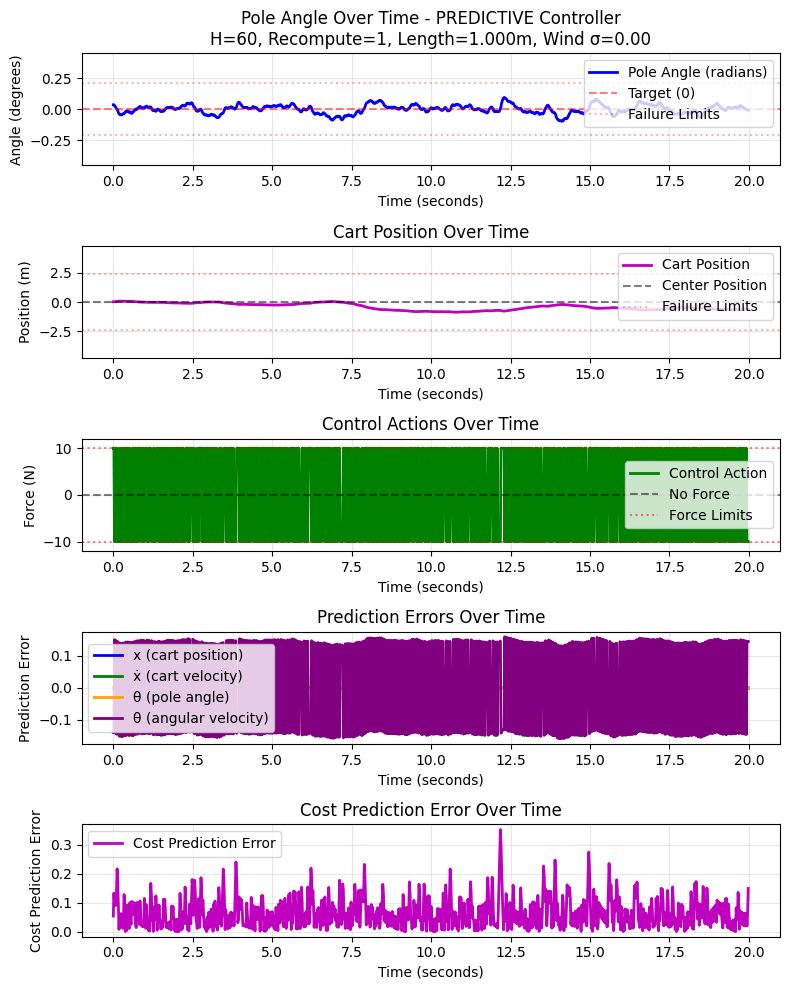

In [5]:
# Run one episode
run_single_episode_with_plots(
    controller_type='predictive', 
    horizon=60,            
    dt=0.02, 
    recompute_every=1, 
    model_length=2.0,      
    wind_mu=0.0, 
    wind_sigma=0.0,        
    episode_length=1000,    
    seed=42
)

## Train and evaluate the models

In [6]:
# Create 'Results' folder if it doesn't exist
results_folder = "../results/PerformanceResults/"

# Make sure the folders exist
for folder in [results_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Lists for timing results
results_records = []

#------------------------------------------------------------------------------------------------------------------------------------------------
# Train/evaluate the MPC model
#------------------------------------------------------------------------------------------------------------------------------------------------
start_time = time.time()
mpc_results = evaluate_mpc_controllers(
        controller='predictive',
        horizons=[10, 30, 50, 70],
        recompute_intervals=[1,2,3,4,5],
        dt = 0.02,
        length_ratios=[1.0, 2.0, 3.0, 4.0],
        wind_mus=[0.0], 
        wind_sigmas=[0.0],
        results_folder="../results/PerformanceResults/",
        episode_length=500,
        num_episodes=1,
        init_angles=[0.0]    )

KeyboardInterrupt: 

## Pole length error

Found data for horizons: [10, 30, 50, 70] steps = ['0.2s', '0.6s', '1.0s', '1.4s']
Found data for recompute intervals: [1, 2, 3, 4, 5] steps = ['0.02s', '0.04s', '0.06s', '0.08s', '0.10s']
Plotting ratios: [1.0, 2.0, 3.0, 4.0]

Plot saved to: ../results/PerformanceResults/mpc_4d_performance_heatmaps_wmu0.0_wsig0.0_iang0.00.png


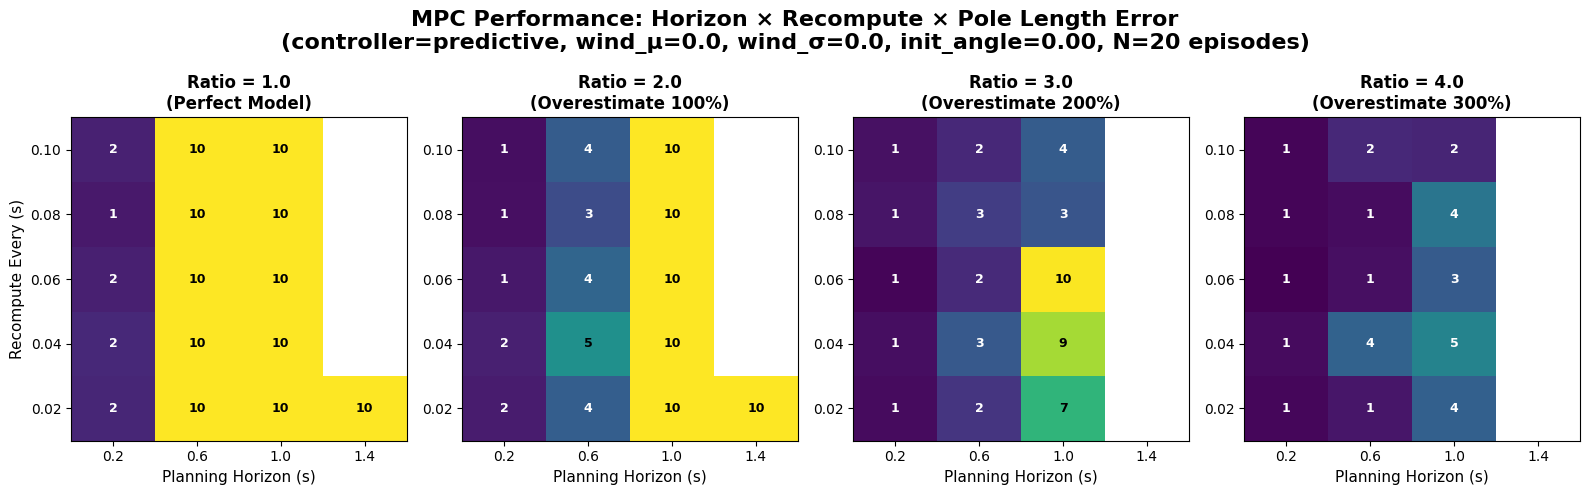

In [7]:
plot_pole_angle_heatmaps(results_folder="../results/PerformanceResults/", 
                                controller='predictive',
                                length_ratios=[1.0, 2.0, 3.0, 4.0],
                                wind_mu=0.0,
                                wind_sigma=0.0,
                                init_angle=0.0)

## Wind sigma error

Found data for horizons: [5, 10, 20, 30] steps = ['0.1s', '0.2s', '0.4s', '0.6s']
Found data for recompute intervals: [1, 2, 3] steps = ['0.02s', '0.04s', '0.06s']
Plotting wind std devs: [0.0, 0.05, 0.1]

Plot saved to: ../results/PerformanceResults/mpc_wind_sigma_heatmaps_r1.0_m0.0_iang0.00.png


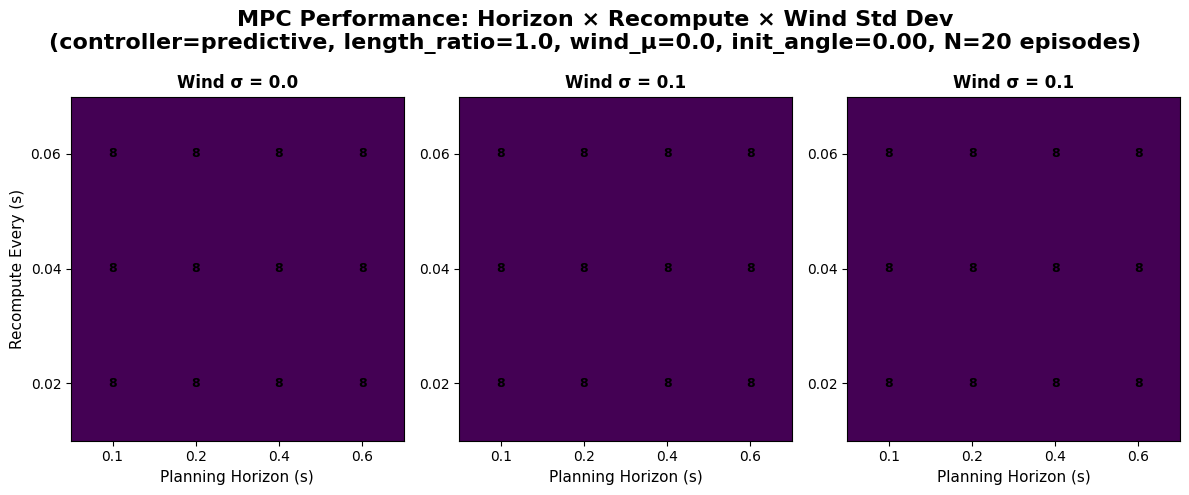

In [10]:
plot_wind_sigma_heatmaps(
    results_folder="../results/PerformanceResults/",
    controller='predictive',
    wind_sigmas=[0.0, 0.05, 0.1],
    length_ratio=1.0,
    wind_mu=0.0,
    init_angle=0.0

)

## Wind error

In [ ]:
plot_wind_mu_heatmaps(
    controller='mpc',
    results_folder="../results/PerformanceResults/",
    wind_mus=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_sigma=0.0,
    init_angle=0.0,
)

No data found for ratio=1.0, sigma=0.0, init_angle=0.0


## Initialization angle

Found data for horizons: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
Found data for recompute intervals: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Plotting initial angles: [0.0, 0.05, 0.1, 0.15]

Plot saved to: ../results/PerformanceResults/mpc_init_angle_heatmaps_r1.0_m0.0_s0.0_ascontinuous.png


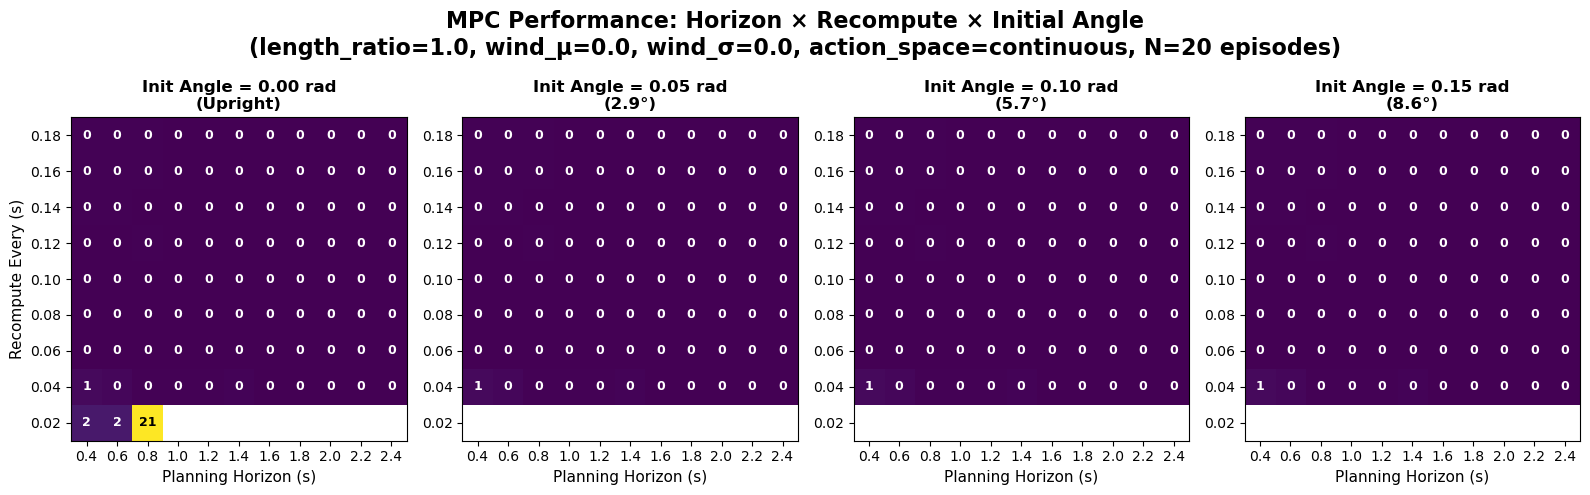

In [ ]:
# Create heatmaps for different initial angles
plot_init_angle_heatmaps(
    controller='mpc',
    init_angles=[0.0, 0.05, 0.1, 0.15],
    length_ratio=1.0,
    wind_mu=0.0,
    wind_sigma=0.0,
    action_space='continuous',
)